## Verification of Unbiased Gradient Estimation

### Objective

The objective of this experiment is to verify whether the stochastic gradient computed from
randomly sampled mini-batches is an unbiased estimate of the true gradient computed using the
entire training dataset.

If the average mini-batch gradient is close to the full-batch gradient, the stochastic gradient
estimator can be considered approximately unbiased.

The experiment is run at the **trained model weights** loaded from a checkpoint, so the result
describes the estimator at the solution SGD actually reached rather than at random initialisation.


### Methodology

1. Load the trained model from a checkpoint.
2. Compute the gradient using the entire training dataset (Full-batch Gradient).
3. Sample multiple random mini-batches of different sizes.
4. Compute the gradient for each mini-batch.
5. Average the mini-batch gradients.
6. Compare the average mini-batch gradient with the full-batch gradient using the relative
   gradient error.


In [1]:
import sys,os
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn.functional as F
from torch.nn import CrossEntropyLoss

from src.utils import load_config, set_seed
from src.data import get_dataloaders
from manual_nn.models import SimpleCNN

os.environ["CUDA_VISIBLE_DEVICES"] = "7"   

In [2]:
# ---- fill this in -------------------------------------------------------
CHECKPOINT_PATH = os.path.join(PROJECT_ROOT, "checkpoints/best_model.pth")
# -------------------------------------------------------------------------

config = load_config(os.path.join(PROJECT_ROOT, "configs/data.yaml"))
model_cfg = load_config(os.path.join(PROJECT_ROOT, "configs/model.yaml"))

set_seed(config.get("seed", 42))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cuda


### Step 0: Load the Trained Model

In [3]:
def load_checkpoint(model, checkpoint_path, device):
    """Load manually-stored weights, same convention as src/tester.py."""
    checkpoint = torch.load(checkpoint_path, map_location=device)

    layer_id = 0
    for layer in model.layers:
        if hasattr(layer, "weights"):
            layer.weights = checkpoint[f"layer_{layer_id}.weights"].to(device)
            layer.bias = checkpoint[f"layer_{layer_id}.bias"].to(device)
            layer_id += 1

    print(f"Loaded {layer_id} parameter layers from {checkpoint_path}")
    return model


model = SimpleCNN(model_cfg).to(device)
model = load_checkpoint(model, CHECKPOINT_PATH, device)
loss_fn = CrossEntropyLoss()


Loaded 4 parameter layers from /vision01_scratch/rajat/et-robo/problem1_mnist/checkpoints/best_model.pth


### Step 1: Compute the Full-batch Gradient

The gradient computed using the entire training dataset is treated as the reference gradient.


In [4]:
full_loader, _, _ = get_dataloaders(
    data_dir=config["root"],
    batch_size=len(get_dataloaders(data_dir=config["root"], batch_size=1)[0].dataset),
    shuffle=False,
)


In [5]:
model.zero_grad()

for x, y in tqdm(full_loader):
    x, y = x.to(device), y.to(device)

    logits = model.forward(x)
    probs = F.softmax(logits, dim=1)
    targets = F.one_hot(y, num_classes=model_cfg["num_classes"]).float()
    grad_logits = (probs - targets) / y.size(0)
    model.backward(grad_logits)

full_grad = [grad.clone() for grad in model.gradients()]

print(f"Number of parameter tensors: {len(full_grad)}")
print(f"Full-batch gradient norm   : {torch.sqrt(sum((g ** 2).sum() for g in full_grad)):.6f}")


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:19<00:00, 19.83s/it]


Number of parameter tensors: 8
Full-batch gradient norm   : 0.415645


### Step 2: Compute Average Mini-batch Gradient

For each batch size, multiple random mini-batches are sampled. The gradient for each mini-batch is
computed and averaged, then compared against the full-batch gradient.


In [6]:
batch_sizes = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512]
num_trials = 200
relative_errors = {}

for batch_size in batch_sizes:
    print("Batch size:", batch_size)

    loader, _, _ = get_dataloaders(data_dir=config["root"], batch_size=batch_size, shuffle=True)

    avg_grad = [torch.zeros_like(g) for g in full_grad]
    count = 0

    for x, y in tqdm(loader, leave=False):
        x, y = x.to(device), y.to(device)

        model.zero_grad()

        logits = model.forward(x)
        probs = F.softmax(logits, dim=1)
        targets = F.one_hot(y, num_classes=model_cfg["num_classes"]).float()
        grad_logits = (probs - targets) / y.size(0)

        model.backward(grad_logits)

        for i, g in enumerate(model.gradients()):
            avg_grad[i] += g

        count += 1
        if count == num_trials:
            break

    avg_grad = [g / count for g in avg_grad]

    num = sum(torch.sum((g_avg - g_full) ** 2) for g_avg, g_full in zip(avg_grad, full_grad))
    den = sum(torch.sum(g_full ** 2) for g_full in full_grad)

    relative_errors[batch_size] = torch.sqrt(num / den).item()


Batch size: 1


Batch size: 2


Batch size: 4


Batch size: 8


Batch size: 16


Batch size: 32


Batch size: 64


Batch size: 128


Batch size: 256


Batch size: 512


### Step 3: Compare with the Full-batch Gradient

The average mini-batch gradient is compared with the full-batch gradient using the
**Relative Gradient Error**,

$$
\frac{\|\bar{g}_{\mathrm{mini}}-g_{\mathrm{full}}\|_2}{\|g_{\mathrm{full}}\|_2}.
$$

A smaller value indicates that the average stochastic gradient is closer to the true gradient,
providing empirical evidence for the unbiased gradient assumption.


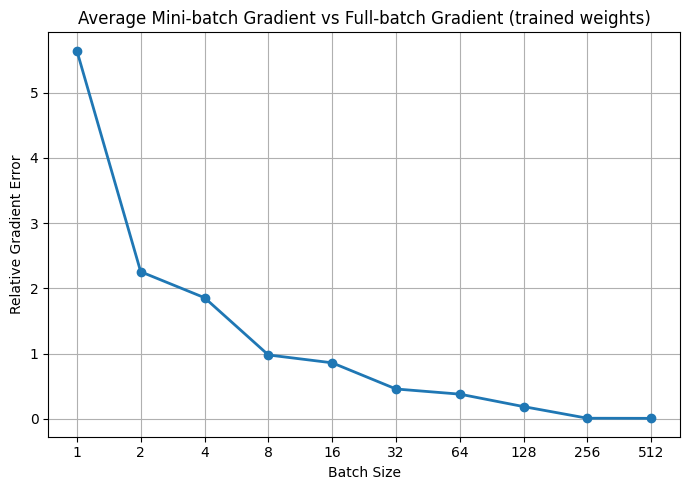

In [7]:
plt.figure(figsize=(7, 5))

plt.plot(list(relative_errors.keys()), list(relative_errors.values()), marker="o", linewidth=2)

plt.xscale("log", base=2)
plt.xticks(batch_sizes, batch_sizes)
plt.xlabel("Batch Size")
plt.ylabel("Relative Gradient Error")
plt.title("Average Mini-batch Gradient vs Full-batch Gradient (trained weights)")
plt.grid(True)

plt.tight_layout()
plt.savefig("fig_unbiased.png", dpi=200)
plt.show()


In [8]:
# values to quote in the report
for bs, err in relative_errors.items():
    print(f"  batch {bs:>4}: relative error {err:.4f}")


  batch    1: relative error 5.6421
  batch    2: relative error 2.2557
  batch    4: relative error 1.8577
  batch    8: relative error 0.9805
  batch   16: relative error 0.8602
  batch   32: relative error 0.4593
  batch   64: relative error 0.3801
  batch  128: relative error 0.1890
  batch  256: relative error 0.0109
  batch  512: relative error 0.0094


### What does this figure tell?

- The relative gradient error decreases as the batch size increases.
- Larger mini-batches produce gradients that are closer to the full-batch gradient.
- The average gradient over multiple randomly sampled mini-batches closely approximates the true
  gradient.
- Because this is measured at the trained weights, the evidence applies to the point SGD actually
  converged to, not only to random initialisation.
- These observations provide empirical evidence that the stochastic gradient is approximately
  **unbiased** for the MNIST dataset.
